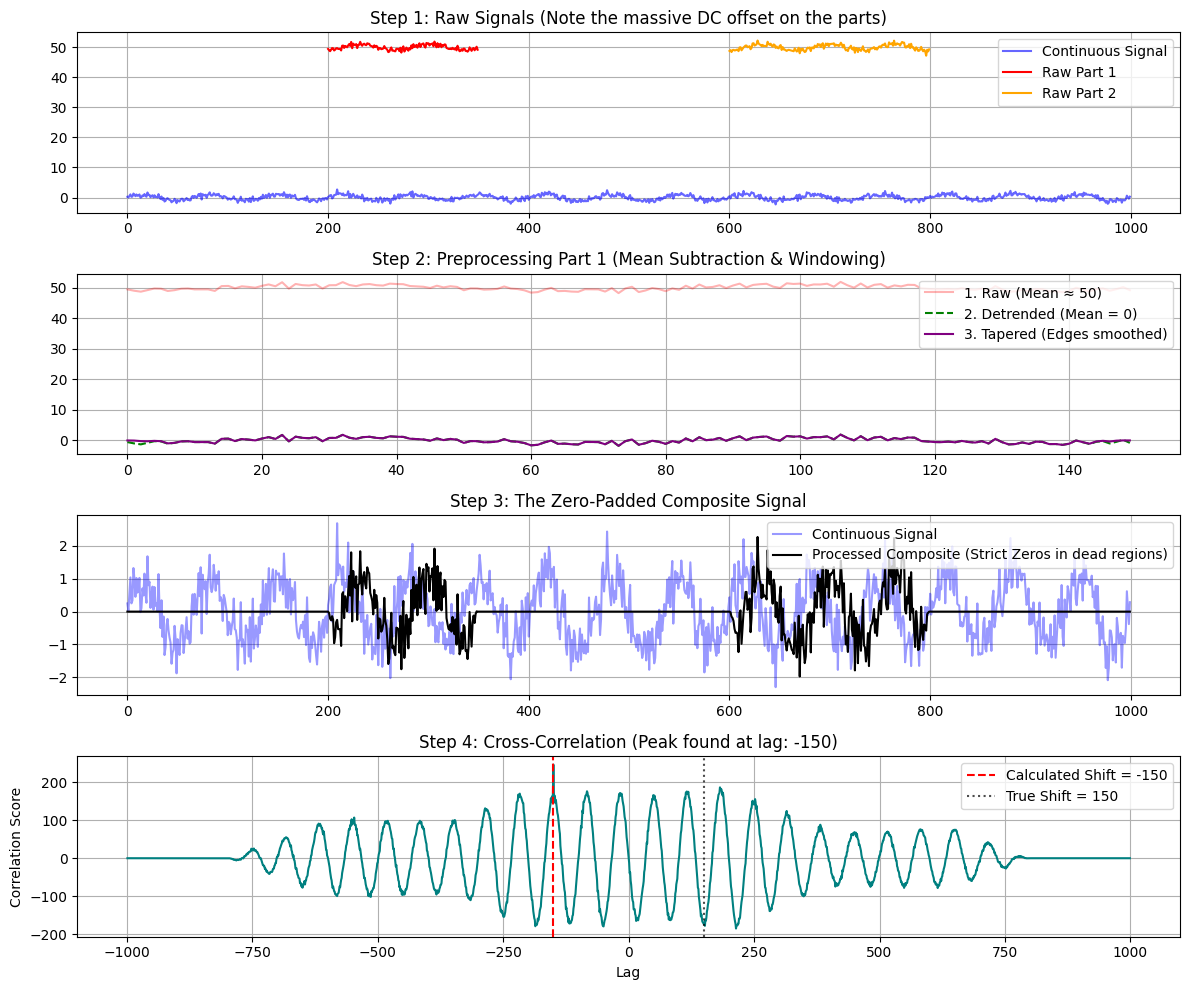

True Time Shift introduced: 150
Calculated Shift via Correlation: -150


In [ ]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP: Create Dummy Data
# ==========================================
np.random.seed(42)
total_length = 1000
true_shift = 150  

t = np.linspace(0, 10, total_length)
continuous_signal = np.sin(2 * np.pi * 1.5 * t) + np.random.normal(0, 0.5, total_length)

part1_start, part1_end = 200, 350
part2_start, part2_end = 600, 800
dc_offset = 50.0 

raw_part1 = continuous_signal[part1_start - true_shift : part1_end - true_shift] 
raw_part1 = raw_part1 + dc_offset + np.random.normal(0, 0.2, 150)

raw_part2 = continuous_signal[part2_start - true_shift : part2_end - true_shift]
raw_part2 = raw_part2 + dc_offset + np.random.normal(0, 0.2, 200)

# --- PLOT 1: Raw Signals ---
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.title("Step 1: Raw Signals (Note the massive DC offset on the parts)")
plt.plot(continuous_signal, label="Continuous Signal", color='blue', alpha=0.6)
# Plotting the raw parts at their intended indices to show the offset
plt.plot(np.arange(part1_start, part1_end), raw_part1, label="Raw Part 1", color='red')
plt.plot(np.arange(part2_start, part2_end), raw_part2, label="Raw Part 2", color='orange')
plt.legend(loc="upper right")
plt.grid(True)

# ==========================================
# 2. THE CRUCIAL PREPROCESSING
# ==========================================
processed_composite = np.zeros(total_length)

def preprocess_part(data):
    detrended = data - np.mean(data)
    window = signal.windows.tukey(len(detrended), alpha=0.1)
    tapered = detrended * window
    return detrended, tapered # Returning both for plotting purposes

detrended_p1, tapered_p1 = preprocess_part(raw_part1)
detrended_p2, tapered_p2 = preprocess_part(raw_part2)

processed_composite[part1_start:part1_end] = tapered_p1
processed_composite[part2_start:part2_end] = tapered_p2

# --- PLOT 2: Preprocessing Step (Zoomed in on Part 1) ---
plt.subplot(4, 1, 2)
plt.title("Step 2: Preprocessing Part 1 (Mean Subtraction & Windowing)")
plt.plot(raw_part1, label="1. Raw (Mean ≈ 50)", color='red', alpha=0.3)
plt.plot(detrended_p1, label="2. Detrended (Mean = 0)", color='green', linestyle='--')
plt.plot(tapered_p1, label="3. Tapered (Edges smoothed)", color='purple')
plt.legend(loc="upper right")
plt.grid(True)

# --- PLOT 3: The Assembled Composite Signal ---
plt.subplot(4, 1, 3)
plt.title("Step 3: The Zero-Padded Composite Signal")
plt.plot(continuous_signal, label="Continuous Signal", color='blue', alpha=0.4)
plt.plot(processed_composite, label="Processed Composite (Strict Zeros in dead regions)", color='black')
plt.legend(loc="upper right")
plt.grid(True)

# ==========================================
# 3. CROSS-CORRELATION
# ==========================================
correlation = signal.correlate(continuous_signal, processed_composite, mode='full')
lags = signal.correlation_lags(len(continuous_signal), len(processed_composite), mode='full')

peak_idx = np.argmax(correlation)
calculated_shift = lags[peak_idx]

# --- PLOT 4: Cross-Correlation Result ---
plt.subplot(4, 1, 4)
plt.title(f"Step 4: Cross-Correlation (Peak found at lag: {calculated_shift})")
plt.plot(lags, correlation, color='teal')
plt.axvline(x=calculated_shift, color='red', linestyle='--', label=f'Calculated Shift = {calculated_shift}')
plt.axvline(x=true_shift, color='black', linestyle=':', alpha=0.7, label=f'True Shift = {true_shift}')
plt.legend(loc="upper right")
plt.grid(True)
plt.xlabel("Lag")
plt.ylabel("Correlation Score")

plt.tight_layout()
plt.show()

print(f"True Time Shift introduced: {true_shift}")
print(f"Calculated Shift via Correlation: {calculated_shift}")

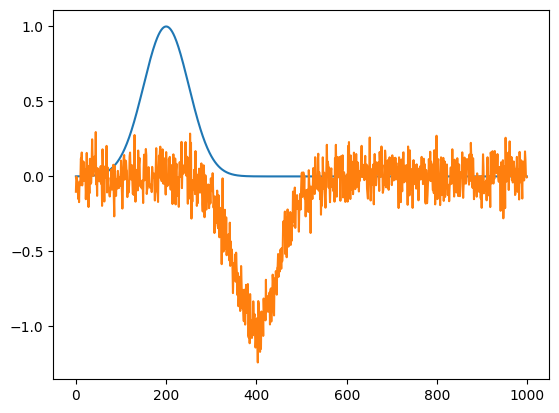

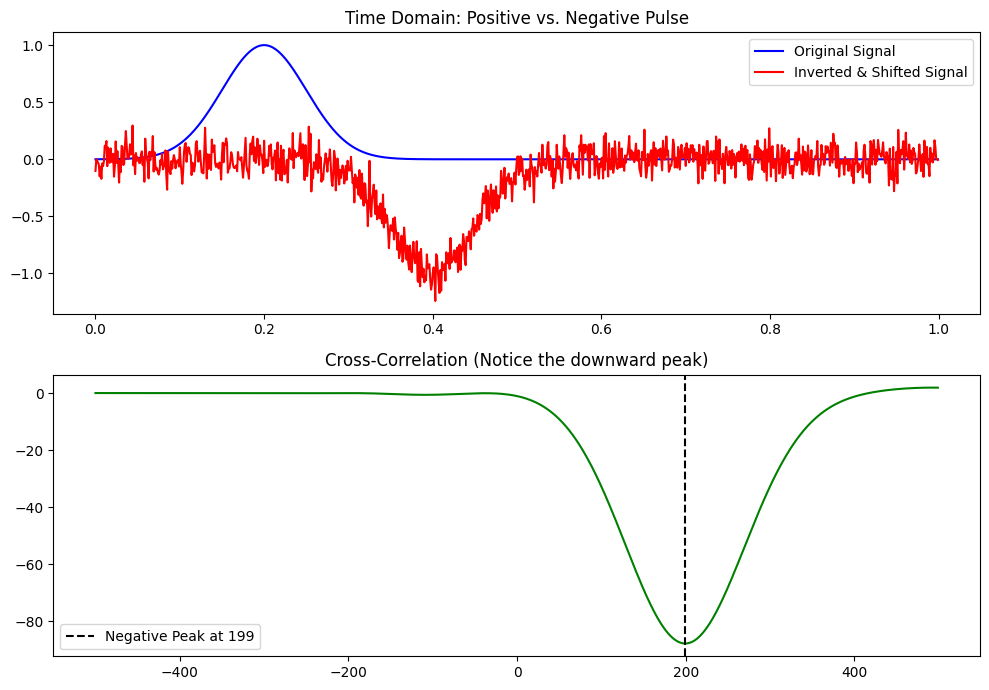

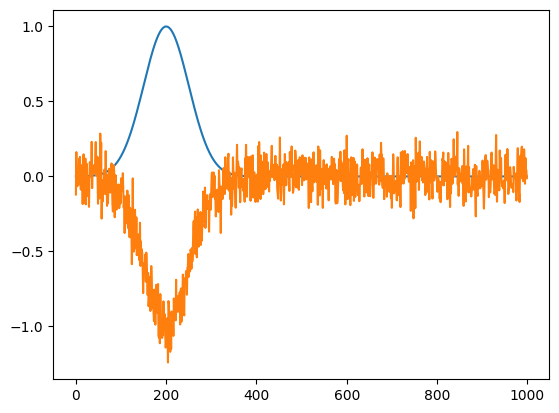

Minimum Correlation Value: -87.83
Estimated Shift (at Min): 199


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parameters
fs = 1000
t = np.arange(0, 1.0, 1/fs)
true_shift = 200  # 200 samples delay

# 1. Create original signal (A pulse)
sig_orig = np.exp(-0.5 * ((t - 0.2) / 0.05)**2)

# 2. Create the "Inverted" and Shifted signal
# We multiply by -1 to create negative correlation
sig_inverted = -1.0 * np.roll(sig_orig, true_shift)
sig_inverted[:true_shift] = 0 # Clean up wrap-around
sig_inverted += np.random.normal(0, 0.1, size=sig_orig.shape) # Add some noise

plt.plot(sig_orig)
plt.plot(sig_inverted)
plt.show()

# 3. Correlate
correlation = signal.correlate(sig_inverted, sig_orig, mode='same')
lags = signal.correlation_lags(len(sig_inverted), len(sig_orig), mode='same')

# For Negative Correlation, we look for the MINIMUM, not the maximum
estimated_shift = lags[np.argmin(correlation)]

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

ax1.plot(t, sig_orig, label='Original Signal', color='blue')
ax1.plot(t, sig_inverted, label='Inverted & Shifted Signal', color='red')
ax1.set_title("Time Domain: Positive vs. Negative Pulse")
ax1.legend()

ax2.plot(lags, correlation, color='green')
ax2.axvline(estimated_shift, color='black', linestyle='--', label=f'Negative Peak at {estimated_shift}')
ax2.set_title("Cross-Correlation (Notice the downward peak)")
ax2.legend()

plt.tight_layout()
plt.show()

plt.plot(sig_orig)
plt.plot(np.roll(sig_inverted, -estimated_shift))
plt.show()

print(f"Minimum Correlation Value: {np.min(correlation):.2f}")
print(f"Estimated Shift (at Min): {estimated_shift}")